<a href="https://colab.research.google.com/github/HimathDissa/NorthStar-Analytics-CP60056E/blob/main/notebooks/NorthStar_Python_Pandas_Workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Install & Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats


sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
#Load Datasets

DATA_PATH = "."

customers  = pd.read_csv(f"{DATA_PATH}/customers.csv")
orders     = pd.read_csv(f"{DATA_PATH}/orders.csv")
deliveries = pd.read_csv(f"{DATA_PATH}/deliveries.csv")
drivers    = pd.read_csv(f"{DATA_PATH}/drivers.csv")
vehicles   = pd.read_csv(f"{DATA_PATH}/vehicles.csv")
hubs       = pd.read_csv(f"{DATA_PATH}/hubs.csv")
incidents  = pd.read_csv(f"{DATA_PATH}/incidents.csv")
complaints = pd.read_csv(f"{DATA_PATH}/complaints.csv")
app_events = pd.read_csv(f"{DATA_PATH}/app_events.csv")

print("All datasets loaded.")
for name, df in [("customers",customers),("orders",orders),("deliveries",deliveries),
                 ("drivers",drivers),("vehicles",vehicles),("hubs",hubs),
                 ("incidents",incidents),("complaints",complaints),("app_events",app_events)]:
    print(f"  {name}: {df.shape[0]} rows × {df.shape[1]} cols")

All datasets loaded.
  customers: 650 rows × 9 cols
  orders: 1250 rows × 11 cols
  deliveries: 950 rows × 13 cols
  drivers: 170 rows × 8 cols
  vehicles: 120 rows × 8 cols
  hubs: 8 rows × 5 cols
  incidents: 280 rows × 7 cols
  complaints: 320 rows × 10 cols
  app_events: 640 rows × 10 cols



=== STEP 1: Missing Value Analysis ===
   dataset                        column  missing_count  missing_pct
 customers                 loyalty_score             20          3.1
 customers             preferred_channel             13          2.0
    orders               booking_channel             25          2.0
deliveries         delivery_completed_at             19          2.0
deliveries customer_rating_post_delivery             14          1.5
   drivers                training_score              7          4.1
  vehicles            battery_health_pct              4          3.3
 incidents                resolved_hours             17          6.1
complaints           compensation_amount             16          5.0
app_events                      order_id            144         22.5


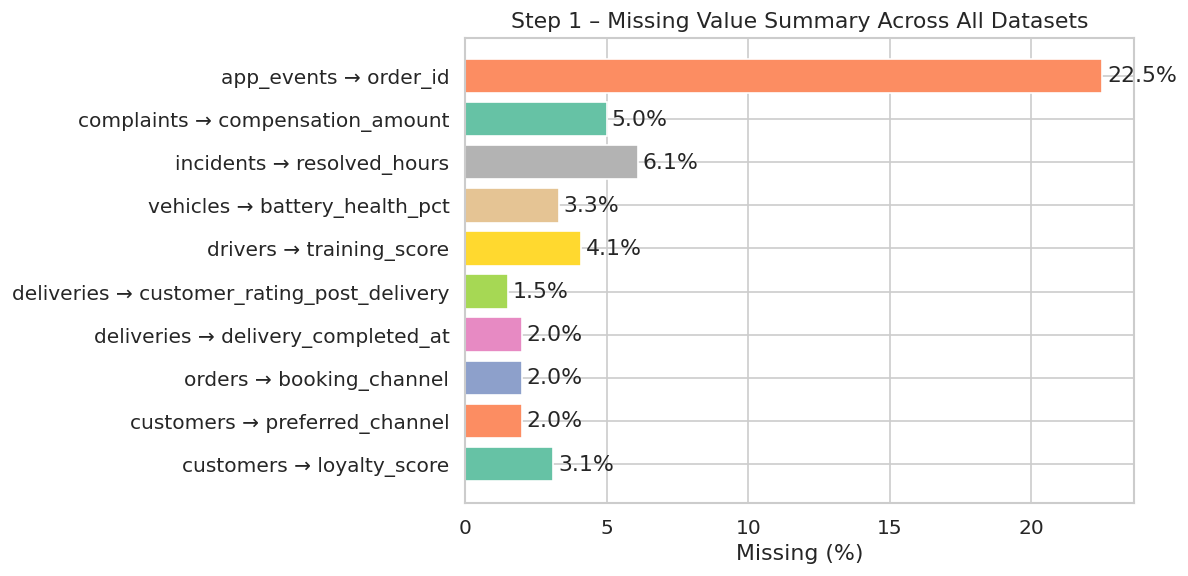

In [ ]:
#1 - MISSING VALUE ANALYSIS

print("\n=== STEP 1: Missing Value Analysis ===")

datasets = {
    "customers": customers, "orders": orders, "deliveries": deliveries,
    "drivers": drivers, "vehicles": vehicles, "incidents": incidents,
    "complaints": complaints, "app_events": app_events
}

missing_summary = []
for name, df in datasets.items():
    for col in df.columns:
        n_miss = df[col].isnull().sum()
        if n_miss > 0:
            missing_summary.append({
                "dataset": name,
                "column": col,
                "missing_count": n_miss,
                "missing_pct": round(100 * n_miss / len(df), 1)
            })

missing_df = pd.DataFrame(missing_summary)
print(missing_df.to_string(index=False))

# Visualise missing values
fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette("Set2", len(missing_df))
bars = ax.barh(
    missing_df["dataset"] + " → " + missing_df["column"],
    missing_df["missing_pct"], color=colors
)
ax.bar_label(bars, labels=[f'{v:.1f}%' for v in missing_df["missing_pct"]], padding=3)
ax.set_xlabel("Missing (%)")
ax.set_title("Step 1 – Missing Value Summary Across All Datasets")
plt.tight_layout()
plt.show()

In [ ]:
#2 - Data Cleaning

print("\n=== STEP 2: Data Cleaning ===")

# --- 2a. Standardise zone names (raw data has north/NORTH/North/Ctr/CENTRAL) ---
ZONE_MAP = {
    "north": "North", "NORTH": "North",
    "south": "South", "SOUTH": "South",
    "east":  "East",  "EAST":  "East",
    "west":  "West",  "WEST":  "West",
    "central": "Central", "CENTRAL": "Central", "Ctr": "Central", "CTR": "Central",
    "airport": "Airport", "AIRPORT": "Airport",
    "riverside": "Riverside", "RIVERSIDE": "Riverside", "RiverSide": "Riverside"
}

def clean_zone(series):
    return series.str.strip().replace(ZONE_MAP)

orders["pickup_zone"]      = clean_zone(orders["pickup_zone"])
orders["dropoff_zone"]     = clean_zone(orders["dropoff_zone"])
customers["home_zone"]     = clean_zone(customers["home_zone"])
drivers["base_zone"]       = clean_zone(drivers["base_zone"])
vehicles["assigned_zone"]  = clean_zone(vehicles["assigned_zone"])
hubs["zone"]               = clean_zone(hubs["zone"])
app_events["zone_context"] = clean_zone(app_events["zone_context"])

print("Zone names standardised. Unique pickup zones now:", sorted(orders["pickup_zone"].unique()))

# --- 2b. Impute missing numeric values ---
# loyalty_score → median imputation (robust to outliers)
median_loyalty = customers["loyalty_score"].median()
customers["loyalty_score"].fillna(median_loyalty, inplace=True)
print(f"loyalty_score: filled {missing_df.loc[missing_df['column']=='loyalty_score','missing_count'].values[0]} NAs with median ({median_loyalty})")

# training_score → median per employment_type (more precise)
drivers["training_score"] = drivers.groupby("employment_type")["training_score"] \
    .transform(lambda x: x.fillna(x.median()))
print("training_score: filled NAs with median per employment_type")

# battery_health_pct → median per vehicle_type
vehicles["battery_health_pct"] = vehicles.groupby("vehicle_type")["battery_health_pct"] \
    .transform(lambda x: x.fillna(x.median()))
print("battery_health_pct: filled NAs with median per vehicle_type")

# compensation_amount → 0 where missing (no compensation was given)
complaints["compensation_amount"].fillna(0, inplace=True)
print("compensation_amount: filled NAs with 0 (no compensation awarded)")

# resolved_hours → median (incident still open; we note separately)
median_resolved = incidents["resolved_hours"].median()
incidents["resolved_hours"].fillna(median_resolved, inplace=True)
print(f"resolved_hours: filled NAs with median ({median_resolved})")

# preferred_channel → mode
mode_channel = customers["preferred_channel"].mode()[0]
customers["preferred_channel"].fillna(mode_channel, inplace=True)

# booking_channel → mode
mode_booking = orders["booking_channel"].mode()[0]
orders["booking_channel"].fillna(mode_booking, inplace=True)

# --- 2c. Parse datetime columns ---
deliveries["dispatch_time"]         = pd.to_datetime(deliveries["dispatch_time"])
deliveries["delivery_completed_at"] = pd.to_datetime(deliveries["delivery_completed_at"])
orders["order_created_at"]          = pd.to_datetime(orders["order_created_at"])
app_events["event_timestamp"]       = pd.to_datetime(app_events["event_timestamp"])
customers["signup_date"]            = pd.to_datetime(customers["signup_date"])

print("\nDatetime columns parsed.")
print("Data cleaning complete — no missing values remain in key columns.\n")


=== STEP 2: Data Cleaning ===
Zone names standardised. Unique pickup zones now: ['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']
loyalty_score: filled 20 NAs with median (59.6)
training_score: filled NAs with median per employment_type
battery_health_pct: filled NAs with median per vehicle_type
compensation_amount: filled NAs with 0 (no compensation awarded)
resolved_hours: filled NAs with median (11.5)

Datetime columns parsed.
Data cleaning complete — no missing values remain in key columns.



/tmp/ipykernel_5434/3744274230.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customers["loyalty_score"].fillna(median_loyalty, inplace=True)
/tmp/ipykernel_5434/3744274230.py:46: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inp

In [ ]:
#3 - Feature Engineering

print("=== STEP 3: Feature Engineering ===")

# Delivery duration in hours
deliveries["actual_duration_hrs"] = (
    deliveries["delivery_completed_at"] - deliveries["dispatch_time"]
).dt.total_seconds() / 3600
# Remove anomalies
deliveries.loc[deliveries["actual_duration_hrs"] < 0,  "actual_duration_hrs"] = np.nan
deliveries.loc[deliveries["actual_duration_hrs"] > 72, "actual_duration_hrs"] = np.nan

# Delivery hour of day (for peak analysis)
deliveries["dispatch_hour"] = deliveries["dispatch_time"].dt.hour

# Order month and day of week
orders["order_month"]   = orders["order_created_at"].dt.to_period("M").astype(str)
orders["order_dow"]     = orders["order_created_at"].dt.day_name()
orders["order_hour"]    = orders["order_created_at"].dt.hour

# Customer tenure in days
customers["tenure_days"] = (pd.Timestamp("today") - customers["signup_date"]).dt.days

# Failure flag on deliveries
deliveries["is_failure"] = deliveries["delivery_status"].isin(["Failed", "Delayed"]).astype(int)

# High severity complaint flag
complaints["is_high_severity"] = complaints["severity"].isin(["High", "Critical"]).astype(int)

print("New features created:")
print("  deliveries: actual_duration_hrs, dispatch_hour, is_failure")
print("  orders:     order_month, order_dow, order_hour")
print("  customers:  tenure_days")
print("  complaints: is_high_severity\n")

=== STEP 3: Feature Engineering ===
New features created:
  deliveries: actual_duration_hrs, dispatch_hour, is_failure
  orders:     order_month, order_dow, order_hour
  customers:  tenure_days
  complaints: is_high_severity



In [ ]:
#4 - Build Master Analytical Table

master = (
    deliveries
    .merge(orders,     on="order_id",    how="left")
    .merge(drivers,    on="driver_id",   how="left")
    .merge(vehicles,   on="vehicle_id",  how="left")
    .merge(customers,  on="customer_id", how="left")
    .merge(hubs,       on="hub_id",      how="left")
)

print(f"=== STEP 4: Master table: {master.shape[0]} rows × {master.shape[1]} cols ===\n")

=== STEP 4: Master table: 950 rows × 56 cols ===



=== ANALYSIS 1: Failure Heatmap – Zone × Service Type ===
service_type  Business  Medical  Parcel  Passenger  Retail
pickup_zone                                               
Airport           38.5     40.0    29.0       50.0    34.5
Central           54.2     46.2    46.3       40.4    55.1
East              38.9     21.1    30.0       37.8    29.4
North             39.1     50.0    22.2       17.1    40.6
Riverside         35.3     28.6    39.3       42.4    29.6
South             52.6     29.4    28.1       17.5    16.1
West              25.0     35.3    25.8       40.6    22.7


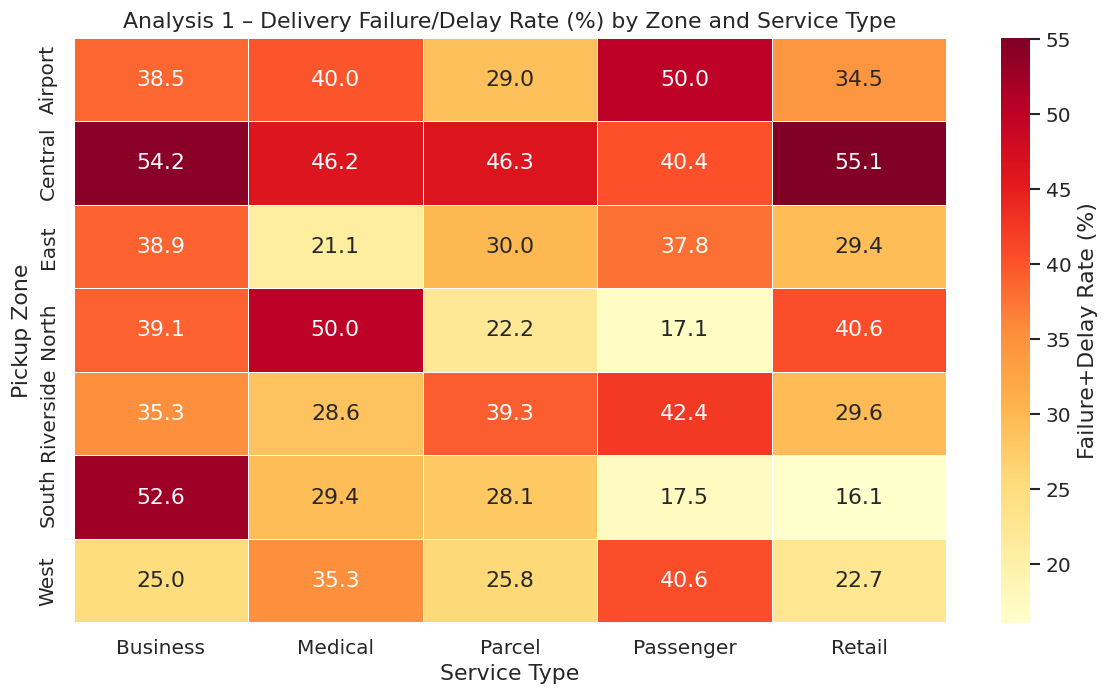

In [ ]:
#Analysis 1 - Failure Rate by Zone & Service Type

print("=== ANALYSIS 1: Failure Heatmap – Zone × Service Type ===")

failure_heat = (
    master.groupby(["pickup_zone", "service_type"])["is_failure"]
    .mean()
    .mul(100).round(1)
    .reset_index()
    .pivot(index="pickup_zone", columns="service_type", values="is_failure")
)

print(failure_heat)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(failure_heat, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Failure+Delay Rate (%)"})
ax.set_title("Analysis 1 – Delivery Failure/Delay Rate (%) by Zone and Service Type")
ax.set_xlabel("Service Type")
ax.set_ylabel("Pickup Zone")
plt.tight_layout()
plt.show()


=== ANALYSIS 2: Peak Hour Demand & Failure Pattern ===


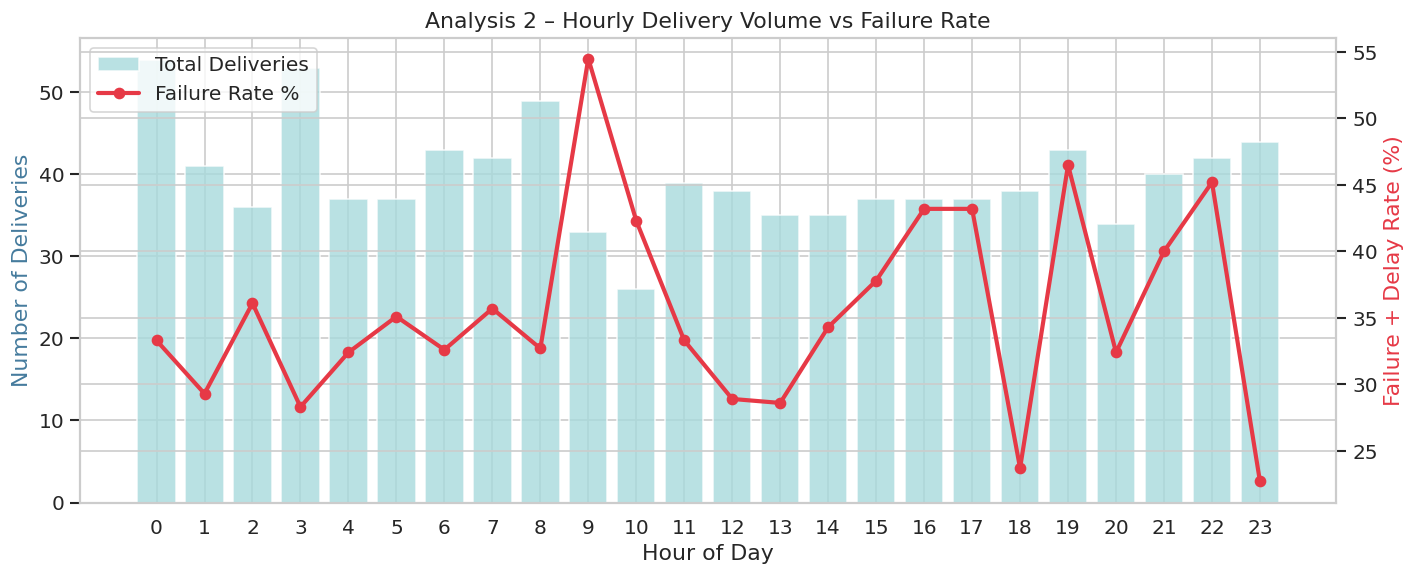

In [ ]:
print("\n=== ANALYSIS 2: Peak Hour Demand & Failure Pattern ===")

hourly = master.groupby("dispatch_hour").agg(
    total_deliveries = ("delivery_id", "count"),
    failures         = ("is_failure",  "sum"),
    avg_rating       = ("customer_rating_post_delivery", "mean")
).reset_index()
hourly["failure_rate_pct"] = (hourly["failures"] / hourly["total_deliveries"] * 100).round(1)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(hourly["dispatch_hour"], hourly["total_deliveries"],
        color="#a8dadc", alpha=0.8, label="Total Deliveries")
ax2.plot(hourly["dispatch_hour"], hourly["failure_rate_pct"],
         color="#e63946", linewidth=2.5, marker="o", label="Failure Rate %")

ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Number of Deliveries", color="#457b9d")
ax2.set_ylabel("Failure + Delay Rate (%)", color="#e63946")
ax1.set_xticks(range(0, 24))
ax1.set_title("Analysis 2 – Hourly Delivery Volume vs Failure Rate")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.show()


=== ANALYSIS 3: App Event Analysis ===
                 event_type  count  mean  median  max    p95
delivery_instruction_update     75 496.3   446.0 1285  924.9
                chat_opened     88 478.3   416.5 1690 1079.1
             chat_escalated     38 478.1   411.0 1402 1083.6
              payment_retry     69 472.7   440.0 1701  863.8
                track_order    138 460.7   427.0 1660  868.7
               search_route     99 456.5   457.0 1265  786.0
                eta_refresh    105 452.2   440.0 1285  802.4
             cancel_attempt     28 417.1   414.0 1039  789.3

App success rate by zone:
zone_context  success_rate  total
   Riverside          90.8     87
     Central          92.5     93
       North          92.5     93
        West          94.7     94
     Airport          95.4     87
       South          95.8     95
        East          96.7     91


/tmp/ipykernel_5434/1595336653.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=app_events, x="api_latency_ms", y="event_type",
/tmp/ipykernel_5434/1595336653.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=zone_success, x="zone_context", y="success_rate",


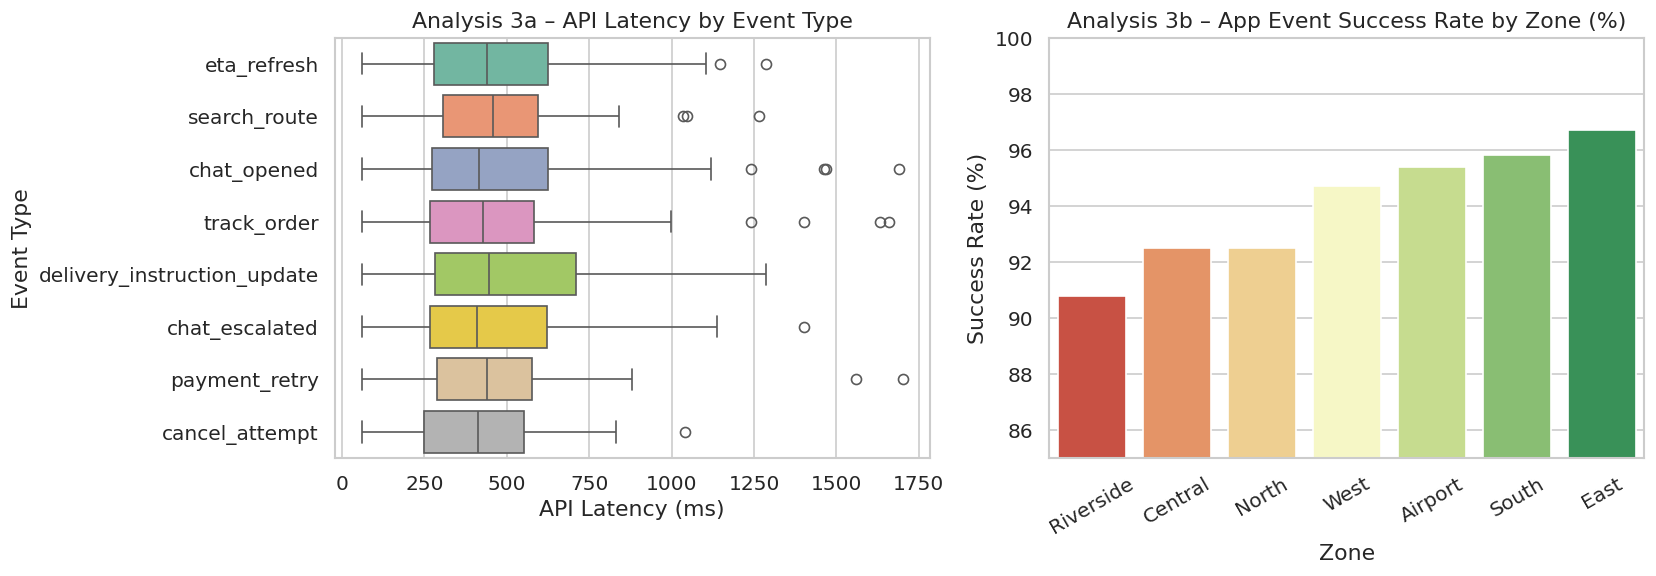

In [ ]:
#Analysis 3 - App Eent Analysis: API Latency & Failure Event

print("\n=== ANALYSIS 3: App Event Analysis ===")

# API latency by event type
latency_summary = app_events.groupby("event_type")["api_latency_ms"].agg(
    count="count", mean="mean", median="median", max="max", p95=lambda x: np.percentile(x, 95)
).round(1).reset_index().sort_values("mean", ascending=False)
print(latency_summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot: latency by event type
sns.boxplot(data=app_events, x="api_latency_ms", y="event_type",
            palette="Set2", ax=axes[0])
axes[0].set_title("Analysis 3a – API Latency by Event Type")
axes[0].set_xlabel("API Latency (ms)")
axes[0].set_ylabel("Event Type")

# Success rate by zone
zone_success = app_events.groupby("zone_context")["success_flag"].agg(
    success_rate=lambda x: round(x.mean() * 100, 1),
    total="count"
).reset_index().sort_values("success_rate")
print("\nApp success rate by zone:")
print(zone_success.to_string(index=False))

sns.barplot(data=zone_success, x="zone_context", y="success_rate",
            palette="RdYlGn", ax=axes[1])
axes[1].set_title("Analysis 3b – App Event Success Rate by Zone (%)")
axes[1].set_xlabel("Zone")
axes[1].set_ylabel("Success Rate (%)")
axes[1].set_ylim(85, 100)
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


=== ANALYSIS 4: Incident Analysis ===
   incident_type  total  avg_resolve_hrs  open_count  critical_count
  CustomerNoShow     44            13.78          12               5
  RouteDeviation     43            13.62          15               4
TemperatureIssue     29            12.92           3               5
    AppSyncError     31            12.55           7               1
    BatteryAlert     36            11.70          11               2
    ProofMissing     46            10.86          12               6
  SafetyNearMiss     14             9.80           3               1
    VehicleFault     37             9.21          14               3


/tmp/ipykernel_5434/317979348.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=incident_summary, x="total", y="incident_type",
/tmp/ipykernel_5434/317979348.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=incident_summary, x="avg_resolve_hrs", y="incident_type",


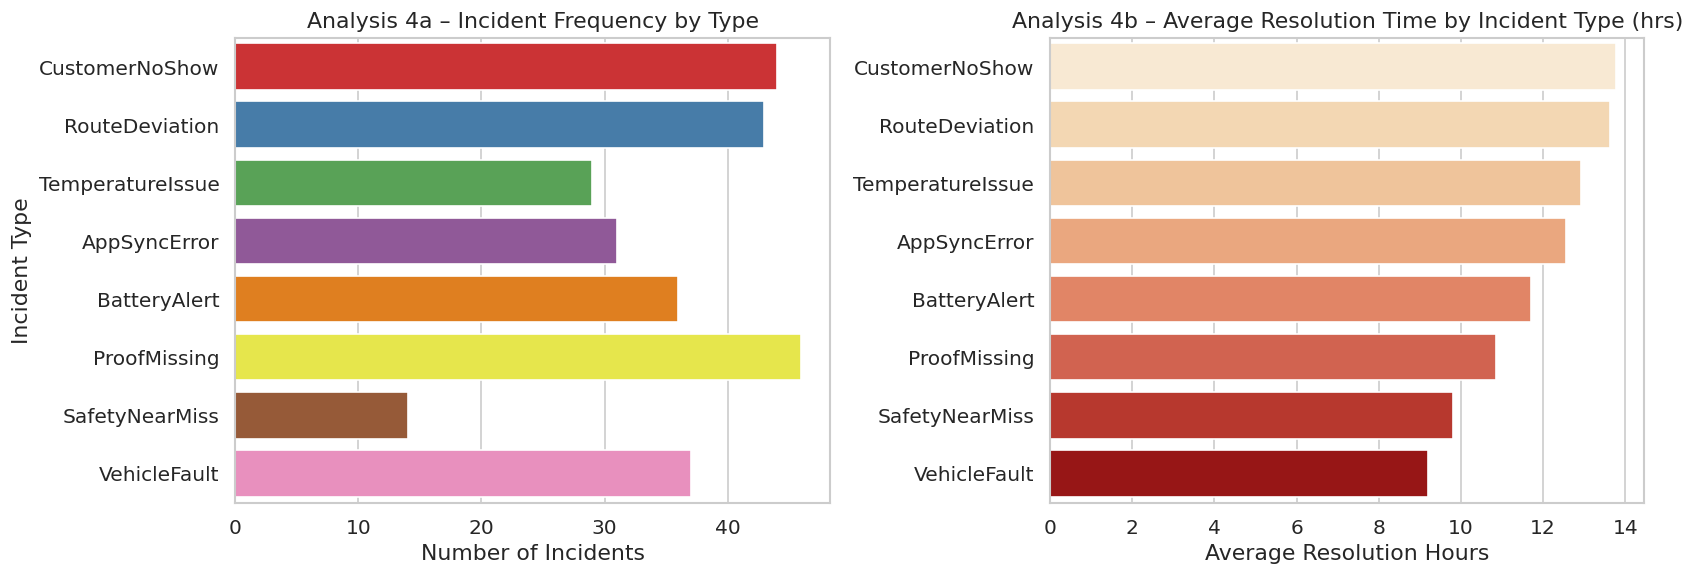

In [ ]:
#Analysis 4 - Incident Type Distribution & Revolution Time

print("\n=== ANALYSIS 4: Incident Analysis ===")

incident_summary = incidents.groupby("incident_type").agg(
    total          = ("incident_id",    "count"),
    avg_resolve_hrs= ("resolved_hours", "mean"),
    open_count     = ("resolution_status", lambda x: (x == "Open").sum()),
    critical_count = ("severity",       lambda x: (x == "Critical").sum())
).round(2).reset_index().sort_values("avg_resolve_hrs", ascending=False)
print(incident_summary.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar: count by incident type
sns.barplot(data=incident_summary, x="total", y="incident_type",
            palette="Set1", ax=axes[0])
axes[0].set_title("Analysis 4a – Incident Frequency by Type")
axes[0].set_xlabel("Number of Incidents")
axes[0].set_ylabel("Incident Type")

# Bar: average resolution hours
sns.barplot(data=incident_summary, x="avg_resolve_hrs", y="incident_type",
            palette="OrRd", ax=axes[1])
axes[1].set_title("Analysis 4b – Average Resolution Time by Incident Type (hrs)")
axes[1].set_xlabel("Average Resolution Hours")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()


=== ANALYSIS 5: Customer Segmentation ===
loyalty_segment engagement_segment  count  avg_age  pct_dormant
     Low (0–40)                Low     14     45.4         14.3
     Low (0–40)             Medium     31     47.9          6.5
     Low (0–40)               High     25     46.8         12.0
 Medium (41–65)                Low     43     46.7         14.0
 Medium (41–65)             Medium    183     45.9         13.7
 Medium (41–65)               High    121     47.7         14.0
  High (66–100)                Low     30     46.8          3.3
  High (66–100)             Medium    108     46.3         12.0
  High (66–100)               High     95     47.5          9.5


/tmp/ipykernel_5434/4093651525.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ctype, x="customer_type", y="count", palette="Set2", ax=axes[1])


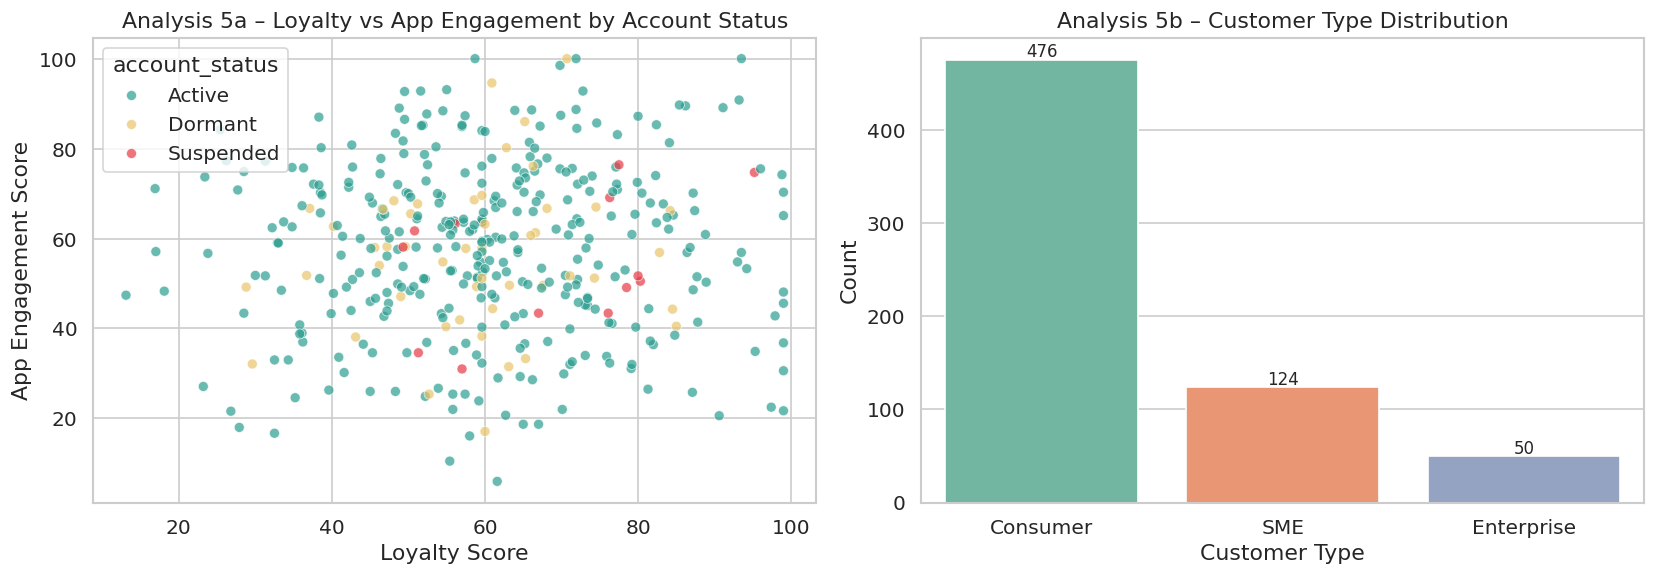

In [ ]:
#Analysis 5 - Customer Segmentation by Behaviour

print("\n=== ANALYSIS 5: Customer Segmentation ===")

# Create segments using NumPy cut
customers["loyalty_segment"] = pd.cut(
    customers["loyalty_score"],
    bins   = [0, 40, 65, 100],
    labels = ["Low (0–40)", "Medium (41–65)", "High (66–100)"]
)
customers["engagement_segment"] = pd.cut(
    customers["app_engagement_score"],
    bins   = [0, 35, 65, 100],
    labels = ["Low", "Medium", "High"]
)

seg_summary = customers.groupby(["loyalty_segment", "engagement_segment"],
                                 observed=True).agg(
    count        = ("customer_id",       "count"),
    avg_age      = ("age",               "mean"),
    pct_dormant  = ("account_status",    lambda x: round(100*(x=="Dormant").mean(),1))
).round(1).reset_index()
print(seg_summary.to_string(index=False))

# Scatter: loyalty vs engagement coloured by account_status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter_data = customers.sample(min(400, len(customers)), random_state=42)
sns.scatterplot(data=scatter_data, x="loyalty_score", y="app_engagement_score",
                hue="account_status", palette={"Active":"#2a9d8f","Dormant":"#e9c46a","Suspended":"#e63946"},
                alpha=0.7, ax=axes[0])
axes[0].set_title("Analysis 5a – Loyalty vs App Engagement by Account Status")
axes[0].set_xlabel("Loyalty Score")
axes[0].set_ylabel("App Engagement Score")

# Bar: customer type distribution
ctype = customers["customer_type"].value_counts().reset_index()
ctype.columns = ["customer_type", "count"]
sns.barplot(data=ctype, x="customer_type", y="count", palette="Set2", ax=axes[1])
axes[1].set_title("Analysis 5b – Customer Type Distribution")
axes[1].set_xlabel("Customer Type")
axes[1].set_ylabel("Count")
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 3,
                 str(int(bar.get_height())), ha='center', fontsize=10)
plt.tight_layout()
plt.show()


=== ANALYSIS 6: Operational Cost Analysis ===
pickup_zone  total_deliveries  avg_cost  total_cost  avg_distance_km  failure_rate  failure_rate_pct
    Airport               113     17.08     1929.80            28.46          0.38              38.0
       East               156     12.57     1960.46            12.05          0.32              32.0
      South               139     12.48     1734.96            12.26          0.26              26.0
  Riverside               119     12.39     1474.70            11.65          0.36              36.0
    Central               174     12.12     2108.94            11.90          0.48              48.0
      North               135     12.07     1629.74            11.23          0.32              32.0
       West               114     11.94     1360.63            12.63          0.31              31.0


/tmp/ipykernel_5434/2886348837.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cost_zone, x="pickup_zone", y="avg_cost",


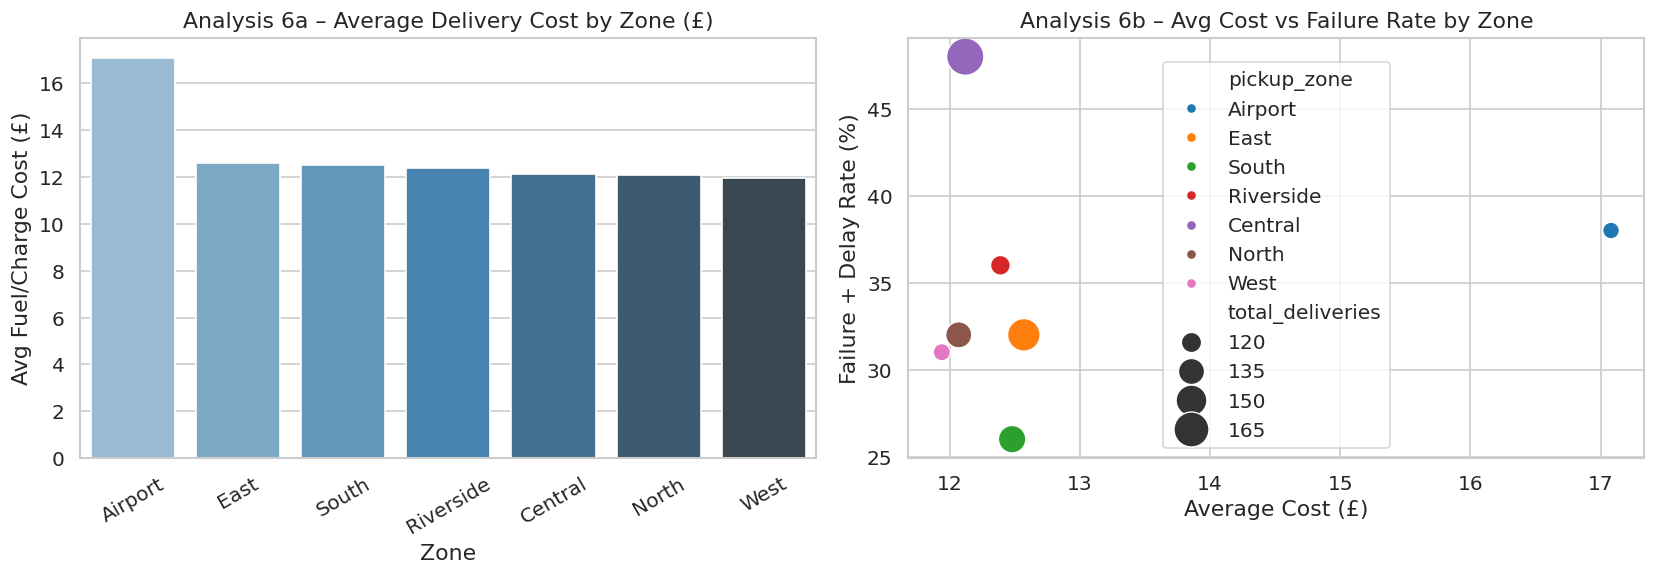

In [ ]:
#Analysis 6 - Operational Cost Analysis

print("\n=== ANALYSIS 6: Operational Cost Analysis ===")

cost_zone = master.groupby("pickup_zone").agg(
    total_deliveries  = ("delivery_id",       "count"),
    avg_cost          = ("fuel_or_charge_cost","mean"),
    total_cost        = ("fuel_or_charge_cost","sum"),
    avg_distance_km   = ("route_distance_km",  "mean"),
    failure_rate      = ("is_failure",         "mean")
).round(2).reset_index().sort_values("avg_cost", ascending=False)
cost_zone["failure_rate_pct"] = (cost_zone["failure_rate"]*100).round(1)
print(cost_zone.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=cost_zone, x="pickup_zone", y="avg_cost",
            palette="Blues_d", ax=axes[0])
axes[0].set_title("Analysis 6a – Average Delivery Cost by Zone (£)")
axes[0].set_xlabel("Zone")
axes[0].set_ylabel("Avg Fuel/Charge Cost (£)")
axes[0].tick_params(axis='x', rotation=30)

# Cost vs failure rate scatter
sns.scatterplot(data=cost_zone, x="avg_cost", y="failure_rate_pct",
                size="total_deliveries", hue="pickup_zone",
                palette="tab10", sizes=(100, 500), ax=axes[1])
axes[1].set_title("Analysis 6b – Avg Cost vs Failure Rate by Zone")
axes[1].set_xlabel("Average Cost (£)")
axes[1].set_ylabel("Failure + Delay Rate (%)")
plt.tight_layout()
plt.show()


=== ANALYSIS 7: Complaint Resolution & Compensation ===
   complaint_type severity  count  avg_resolution_days  total_compensation  avg_compensation  pct_unresolved
            Delay   Medium     56                 5.96              964.87             17.23            28.6
     MissedPickup     High     16                11.56              689.11             43.07             0.0
     MissedPickup   Medium     37                 6.16              644.80             17.43            29.7
            Delay     High     18                12.44              511.54             28.42            44.4
  DriverBehaviour   Medium     31                 5.42              476.29             15.36            22.6
  DriverBehaviour     High     16                13.75              460.63             28.79            31.2
         AppIssue     High     13                13.92              408.59             31.43            23.1
         AppIssue   Medium     25                 7.36              386

/tmp/ipykernel_5434/132469532.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comp_type, x="total_compensation", y="complaint_type",
/tmp/ipykernel_5434/132469532.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=complaints, x="status", y="resolution_days",


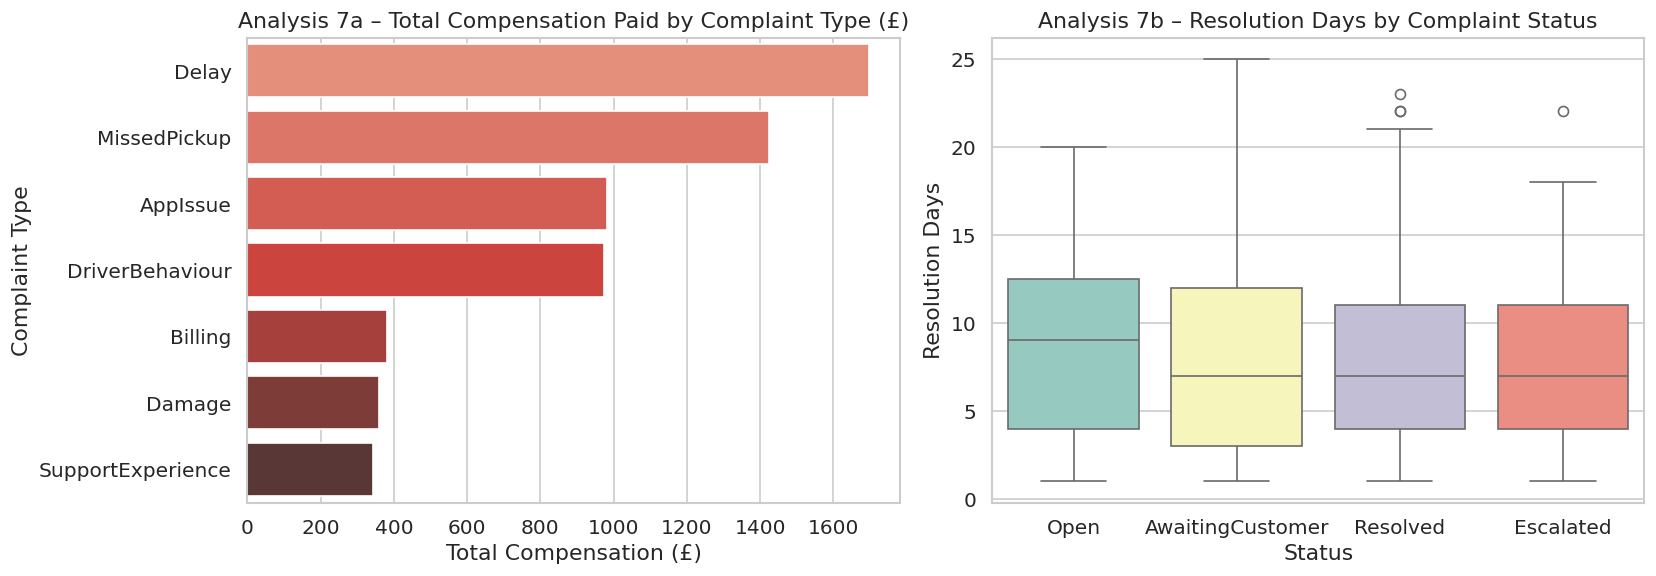

In [ ]:
# Analysis 7 - Complaint Resolution & Compensation Analysis

print("\n=== ANALYSIS 7: Complaint Resolution & Compensation ===")

comp_summary = complaints.groupby(["complaint_type", "severity"]).agg(
    count               = ("complaint_id",       "count"),
    avg_resolution_days = ("resolution_days",    "mean"),
    total_compensation  = ("compensation_amount","sum"),
    avg_compensation    = ("compensation_amount","mean"),
    pct_unresolved      = ("status", lambda x: round(100*x.isin(["Open","Escalated"]).mean(),1))
).round(2).reset_index().sort_values("total_compensation", ascending=False)
print(comp_summary.head(10).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total compensation by complaint type
comp_type = complaints.groupby("complaint_type")["compensation_amount"].sum().reset_index()
comp_type.columns = ["complaint_type","total_compensation"]
comp_type = comp_type.sort_values("total_compensation", ascending=False)
sns.barplot(data=comp_type, x="total_compensation", y="complaint_type",
            palette="Reds_d", ax=axes[0])
axes[0].set_title("Analysis 7a – Total Compensation Paid by Complaint Type (£)")
axes[0].set_xlabel("Total Compensation (£)")
axes[0].set_ylabel("Complaint Type")

# Resolution days by status
sns.boxplot(data=complaints, x="status", y="resolution_days",
            palette="Set3", ax=axes[1])
axes[1].set_title("Analysis 7b – Resolution Days by Complaint Status")
axes[1].set_xlabel("Status")
axes[1].set_ylabel("Resolution Days")
plt.tight_layout()
plt.show()


=== ANALYSIS 8: NumPy Statistical Outlier Detection ===
Delivery Duration (hrs): mean=10.32, std=8.46, p95=24.83, p99=36.61, outliers(|z|>2.5)=21
Fuel/Charge Cost (£): mean=12.84, std=4.33, p95=20.15, p99=23.39, outliers(|z|>2.5)=9
Route Distance (km): mean=13.91, std=7.47, p95=30.17, p99=36.62, outliers(|z|>2.5)=34


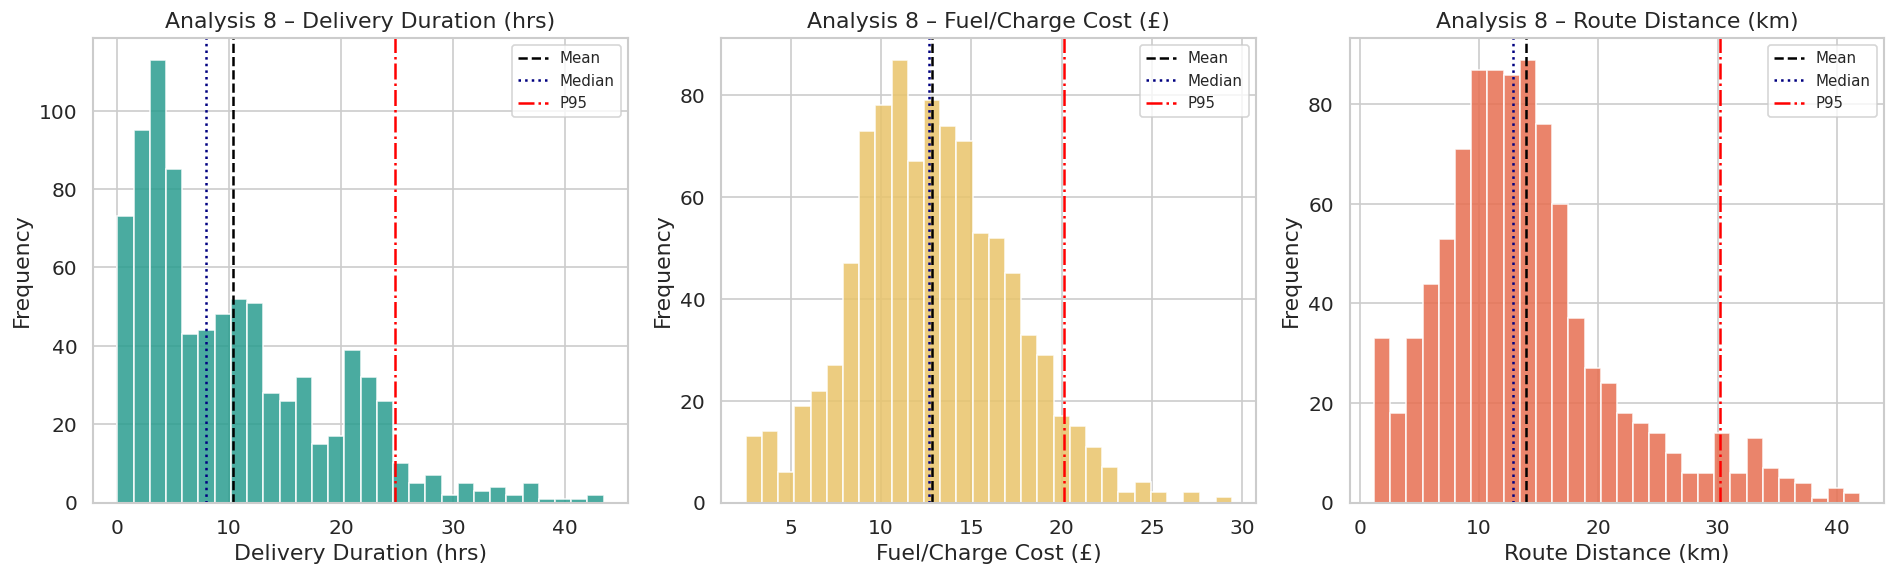


=== All Python data processing analyses complete. ===


In [ ]:
#Analysis 8 - NumPy Statistical Summary : Delivery Performance Metrics

print("\n=== ANALYSIS 8: NumPy Statistical Outlier Detection ===")

dur   = master["actual_duration_hrs"].dropna().values
cost  = master["fuel_or_charge_cost"].dropna().values
dist  = master["route_distance_km"].dropna().values

for label, arr in [("Delivery Duration (hrs)", dur),
                   ("Fuel/Charge Cost (£)",    cost),
                   ("Route Distance (km)",      dist)]:
    z      = np.abs(stats.zscore(arr))
    p95    = np.percentile(arr, 95)
    p99    = np.percentile(arr, 99)
    n_out  = np.sum(z > 2.5)
    print(f"{label}: mean={arr.mean():.2f}, std={arr.std():.2f}, "
          f"p95={p95:.2f}, p99={p99:.2f}, outliers(|z|>2.5)={n_out}")

# Distribution plots for the three key metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, arr, label, color in zip(
        axes,
        [dur, cost, dist],
        ["Delivery Duration (hrs)", "Fuel/Charge Cost (£)", "Route Distance (km)"],
        ["#2a9d8f", "#e9c46a", "#e76f51"]):
    ax.hist(arr, bins=30, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(np.mean(arr),   color="black",  linestyle="--", linewidth=1.5, label="Mean")
    ax.axvline(np.median(arr), color="navy",   linestyle=":",  linewidth=1.5, label="Median")
    ax.axvline(np.percentile(arr, 95), color="red", linestyle="-.", linewidth=1.5, label="P95")
    ax.set_title(f"Analysis 8 – {label}")
    ax.set_xlabel(label)
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\n=== All Python data processing analyses complete. ===")